In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hmean


In [2]:
file_name = "Model_prediction_scores.pkl"  # Name der Datei
file_paths_list = []  # Liste zum Speichern der Pfade

for root, _, files in os.walk("."):  # Durchsuche das aktuelle Verzeichnis und Unterordner
    if file_name in files:
        file_paths_list.append(os.path.join(root, file_name)) 

In [3]:
file_paths_list

['.\\Model_prediction_scores.pkl',
 '.\\Prediction_Classes_Data\\Text\\Model_prediction_scores.pkl',
 '.\\Prediction_Classes_Data\\Theses\\Model_prediction_scores.pkl',
 '.\\Prediction_Data\\Text\\Model_prediction_scores.pkl',
 '.\\Prediction_Data\\Theses\\Model_prediction_scores.pkl',
 '.\\SpaCy_Prediction_Data\\Text\\Model_prediction_scores.pkl',
 '.\\SpaCy_Prediction_Data\\These\\Model_prediction_scores.pkl']

In [4]:
pd.read_pickle('.\\Prediction_Classes_Data\\Text\\Model_prediction_scores.pkl')

,model,lable_text_column,party_text_column,Manifesto_sorted,accuracy,precision,recall,f1
0,paraphrase_multilingual_mpnet_base_v2,These,Text,class prefitted,0.162281,0.228529,0.392523,0.147202
1,paraphrase_multilingual_mpnet_base_v2,These_no_stopwords,Text_no_stopwords,class prefitted,0.197368,0.210020,0.386639,0.176223
2,paraphrase_multilingual_mpnet_base_v2,These_lemmatized,Text_lemmatized,class prefitted,0.162281,0.354382,0.361838,0.148640
3,sbert_hashtag_german_politicians_2021,These,Text,class prefitted,0.280702,0.331905,0.369660,0.243774
4,sbert_hashtag_german_politicians_2021,These_no_stopwords,Text_no_stopwords,class prefitted,0.289474,0.332745,0.376253,0.256797
5,sbert_hashtag_german_politicians_2021,These_lemmatized,Text_lemmatized,class prefitted,0.285088,0.322655,0.357614,0.248823
6,paraphrase_multilingual_MiniLM_L12_v2,These,Text,class prefitted,0.122807,0.236635,0.364486,0.106374
7,paraphrase_multilingual_MiniLM_L12_v2,These_no_stopwords,Text_no_stopwords,class prefitted,0.162281,0.231230,0.377120,0.148697
8,paraphrase_multilingual_MiniLM_L12_v2,These_lemmatized,Text_lemmatized,class prefitted,0.149123,0.214059,0.383178,0.133731


In [5]:
Model_prediction_scores = pd.concat([pd.read_pickle(file_path) for file_path in file_paths_list], ignore_index=True)


In [6]:
Model_prediction_scores.columns


Index(['model', 'lable_text_column', 'party_text_column', 'Manifesto_sorted',
       'accuracy', 'precision', 'recall', 'f1'],
      dtype='object')

In [7]:
Model_prediction_scores['combined_score'] = Model_prediction_scores.apply(lambda row: hmean([row['accuracy'], row['f1']]), axis=1)
Model_prediction_scores.sort_values(by='combined_score', ascending=False).head(10)

,model,lable_text_column,party_text_column,Manifesto_sorted,accuracy,precision,recall,f1,combined_score
17,sbert_hashtag_german_politicians_2021,These_unique_words,These_unique_words,class prefitted,0.451754,0.408187,0.415348,0.356392,0.398447
16,sbert_hashtag_german_politicians_2021,These_lemmatized,These_lemmatized,class prefitted,0.451754,0.408187,0.415348,0.356392,0.398447
15,sbert_hashtag_german_politicians_2021,These_no_stopwords,These_no_stopwords,class prefitted,0.447368,0.391432,0.396709,0.343565,0.388655
14,sbert_hashtag_german_politicians_2021,These,These,class prefitted,0.442982,0.388996,0.393594,0.340624,0.385118
0,manifestoberta-xlm-roberta-56policy-topics-con...,These,These,class prefitted,0.438596,0.367677,0.375075,0.330065,0.376669
66,SpaCy_de_core_news_lg,These_lemmatized,Text_lemmatized,False,0.473684,0.324405,0.367255,0.274101,0.347258
64,SpaCy_de_core_news_lg,These,Text,False,0.473684,0.291779,0.367255,0.272112,0.345658
65,SpaCy_de_core_news_lg,These_no_stopwords,Text_no_stopwords,False,0.473684,0.291779,0.367255,0.272112,0.345658
68,SpaCy_de_core_news_lg,These_no_stopwords,These_no_stopwords,False,0.469298,0.268769,0.364140,0.268322,0.341430
29,sbert_hashtag_german_politicians_2021,These_no_stopwords,Text_no_stopwords,True,0.438596,0.422580,0.342938,0.265913,0.331091


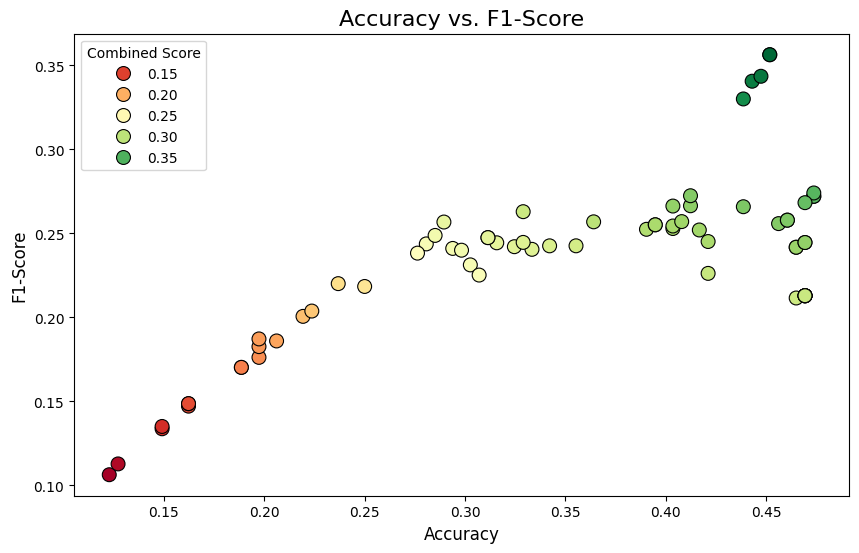

In [8]:
# Erstelle den Scatterplot mit Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='accuracy', y='f1', hue='combined_score', data=Model_prediction_scores, palette='RdYlGn', s=100, edgecolor='black')

# Hinzufügen von Titel und Labels
plt.title('Accuracy vs. F1-Score', fontsize=16)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)

# Zeige den Plot an
plt.legend(title='Combined Score')
plt.show()